# AI: Fundamentals and Applications
## Practical Work 1 — Iris flowers

**Level:** bachelor students  
**Lesson:** 1  
**Time:** 2 hours  
**Difficulty:** beginner  
**Dataset:** Iris flowers

In this work I train a simple AI model. I do not need hard math for this lesson.

### What I will learn

After this work I can:

1. explain the words *example*, *feature*, *label*, *training*, *prediction*, and *accuracy*;
2. look at a small dataset and make graphs;
3. split data into a training set and a testing set;
4. train a k-nearest-neighbours classifier;
5. predict the class of new flowers;
6. check the answers with accuracy and a confusion matrix;
7. say why an AI result is not always perfect.


## 1. What do I ask the computer to do?

The dataset has numbers about Iris flowers. Each flower is one of three kinds:

- **setosa**;
- **versicolor**;
- **virginica**.

The computer gets **four numbers** and must **guess the kind**.

| AI word | Meaning here |
|---|---|
| Example | One flower |
| Feature | One number about the flower |
| Label | The true kind of the flower |
| Training | The model learns from flowers we already know |
| Prediction | The model's answer for a flower |
| Classification | The model chooses one group from some groups |

This is **supervised learning**. I know this because each training flower already has the correct label.

### Checkpoint 1

I write the meaning of each word in simple English.

**Example** means one flower.  
**Feature** means a number I give to the model. Here I have sepal length, sepal width, petal length, and petal width.  
**Label** means the true answer: the kind of flower.  
**Training** means the model looks at known flowers and learns patterns.  
**Prediction** means the model gives an answer for a new flower.  
**Accuracy** means how many answers are correct.  
**Classification** means the model chooses one class from a few classes.


## 2. Import the tools

I import Python libraries. Then I can focus on the AI steps. I do not write the algorithm from formulas.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

RANDOM_STATE = 42


## 3. Load the dataset

`X` has the four input features. `y` has the correct class numbers.

| Feature number | Feature |
|---|---|
| 0 | Sepal length |
| 1 | Sepal width |
| 2 | Petal length |
| 3 | Petal width |

Sepal is the small green leaf under the flower. Petal is the colorful part of the flower.


In [3]:
iris = load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names

print("Number of flowers:", len(X))
print("Number of features:", X.shape[1])
print("Class names:", class_names)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Number of flowers: 150
Number of features: 4
Class names: ['setosa' 'versicolor' 'virginica']
Shape of X: (150, 4)
Shape of y: (150,)


**What do the shapes mean?**

- `X.shape` is `(150, 4)` because I have 150 flowers and 4 numbers for each flower.
- `y.shape` is `(150,)` because each flower has one correct label.


In [4]:
X


array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [5]:
y


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [6]:
flowers = pd.DataFrame(X, columns=iris.feature_names)
flowers["species"] = class_names[y]
display(flowers.head(10))


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## 4. Explore the data

First I count how many flowers I have in each class.


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


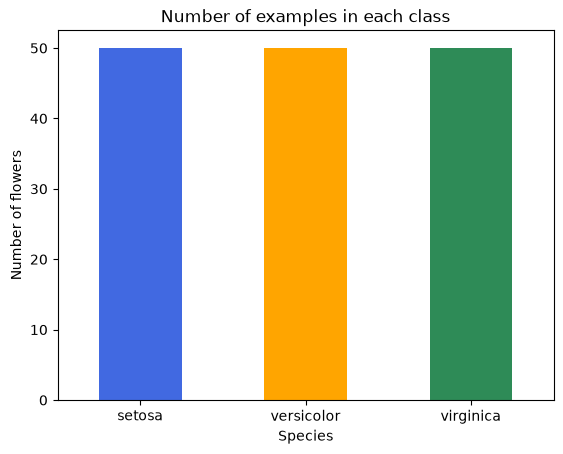

In [7]:
class_counts = flowers["species"].value_counts()
print(class_counts)

class_counts.plot(kind="bar", color=["royalblue", "orange", "seagreen"])
plt.title("Number of examples in each class")
plt.xlabel("Species")
plt.ylabel("Number of flowers")
plt.xticks(rotation=0)
plt.show()


The next graph uses only petal length and petal width. Each point is one flower.


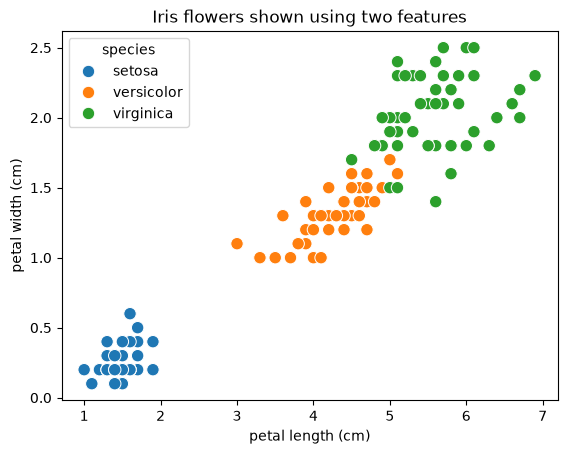

In [8]:
sns.scatterplot(
    data=flowers,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    s=80,
)
plt.title("Iris flowers shown using two features")
plt.show()


### Checkpoint 2

**1. Is the dataset balanced? Explain using the class counts.**  
Yes. Each class has 50 flowers: setosa 50, versicolor 50, virginica 50. No class is bigger than the others.

**2. Which species is visually easiest to separate?**  
Setosa. On the graph, setosa points are far from the other points. These flowers have small petals.

**3. Do versicolor and virginica overlap?**  
Yes. Some points of these two kinds sit in the same place.

**4. Why might overlapping classes cause prediction errors?**  
If two kinds look similar, the model can mix them. A flower in the overlap area can have neighbours from two classes. Then the vote can be wrong.


## 5. Divide data into training and testing sets

I must not test the model on the same flowers it used for learning.

- **Training set:** flowers the model uses to learn.
- **Testing set:** new flowers I use to check the model.

I use 80% for training and 20% for testing. `random_state` makes the same split every time. `stratify=y` keeps all three kinds in both sets.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))
print("Training class counts:", np.bincount(y_train))
print("Testing class counts:", np.bincount(y_test))


Training examples: 120
Testing examples: 30
Training class counts: [40 40 40]
Testing class counts: [10 10 10]


## 6. Put features on a similar scale

The model compares distance between flowers. A feature with big numbers can change the distance too much. Standardization makes the numbers more similar.

**Important rule:** I learn the scale from the training data only. Then I use the same scale for the test data. If I use the test data here, the test is not fair.


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First original training example:", X_train[0])
print("First scaled training example:", X_train_scaled[0].round(3))


First original training example: [4.4 2.9 1.4 0.2]
First scaled training example: [-1.722 -0.332 -1.346 -1.323]


## 7. Train the first AI model

I use **k-nearest neighbours**, or k-NN.

For a new flower, k-NN:

1. finds the nearest known flowers;
2. looks at their labels;
3. chooses the most common label.

When `n_neighbors=3`, the model asks the 3 nearest training flowers to vote.


In [11]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_scaled, y_train)
print("The model has been trained.")


The model has been trained.


`.fit()` is the training step. The computer uses the training flowers and their labels to prepare the model.


## 8. Make predictions

Now the model predicts the kind of the 30 test flowers. These flowers were not used in training.


In [12]:
y_pred = knn_model.predict(X_test_scaled)

comparison = pd.DataFrame({
    "Correct species": class_names[y_test],
    "Predicted species": class_names[y_pred],
    "Correct?": y_test == y_pred,
})
display(comparison)


,Correct species,Predicted species,Correct?
0,setosa,setosa,True
1,virginica,virginica,True
2,versicolor,versicolor,True
3,versicolor,versicolor,True
4,setosa,setosa,True
5,versicolor,versicolor,True
6,setosa,setosa,True
7,setosa,setosa,True
8,virginica,virginica,True
9,versicolor,versicolor,True


I can also ask the model about one flower.

**Why do I use `reshape(1, -1)`?**  
The model wants a table with 2 sizes: (number of flowers, number of features). One flower has 4 features, so I change the shape from `(4,)` to `(1, 4)`.


In [13]:
flower_number = 0
one_flower = X_test_scaled[flower_number].reshape(1, -1)
one_prediction = knn_model.predict(one_flower)[0]

print("Original measurements:", X_test[flower_number])
print("Correct species:", class_names[y_test[flower_number]])
print("Predicted species:", class_names[one_prediction])


Original measurements: [4.4 3.  1.3 0.2]
Correct species: setosa
Predicted species: setosa


## 9. Evaluate the model

Accuracy is the share of correct answers:

\[
\text{Accuracy} = \frac{\text{number of correct predictions}}{\text{total number of predictions}}
\]


In [14]:
accuracy = accuracy_score(y_test, y_pred)
correct_predictions = np.sum(y_test == y_pred)

print("Correct predictions:", correct_predictions, "out of", len(y_test))
print("Accuracy:", round(accuracy, 3))
print("Accuracy percentage:", round(accuracy * 100, 1), "%")
print()
print(classification_report(y_test, y_pred, target_names=class_names))


Correct predictions: 28 out of 30
Accuracy: 0.933
Accuracy percentage: 93.3 %

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



A **confusion matrix** shows which classes are correct and which classes the model mixes.

- rows are the true classes;
- columns are the predicted classes;
- numbers on the diagonal are correct answers;
- numbers outside the diagonal are mistakes.


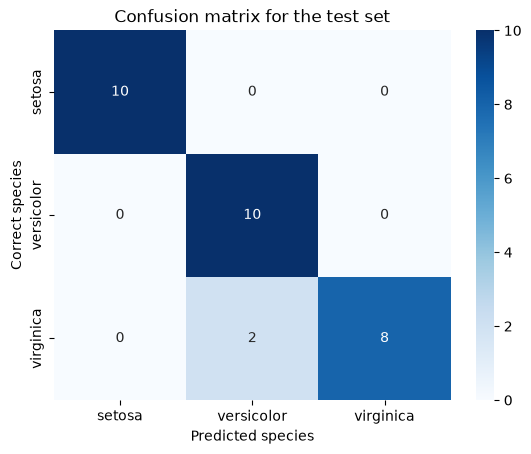

In [15]:
matrix = confusion_matrix(y_test, y_pred)

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted species")
plt.ylabel("Correct species")
plt.title("Confusion matrix for the test set")
plt.show()


### Checkpoint 3

**1. How many predictions were correct?**  
28 out of 30. Accuracy is 0.933. This is 93.3%.

**2. Which species were confused, if any?**  
Setosa is all correct (10 of 10). Versicolor is also all correct. Two virginica flowers are called versicolor. This matches the graph: these two kinds overlap.

**3. Does high accuracy prove that the model will always be correct in the real world?**  
No. I only test 30 flowers from one small dataset. Real flowers can be different. A high score is useful, but it is not a full proof.

**4. Why is it important that the testing flowers were not used during training?**  
If I test on the same flowers, the score can look too good. The test shows if the model can work with new flowers.


## 10. Required student experiment — Change k

The value **k** says how many neighbours can vote.

I run the next cell for k = 1, 3, 5, 7, 9. I replace `None` with the accuracy line.


In [16]:
experiment_results = []

for k in [1, 3, 5, 7, 9]:
    experiment_model = KNeighborsClassifier(n_neighbors=k)
    experiment_model.fit(X_train_scaled, y_train)
    experiment_predictions = experiment_model.predict(X_test_scaled)
    # TODO: Replace None with the accuracy calculation.
    experiment_accuracy = accuracy_score(y_test, experiment_predictions)
    experiment_results.append({
        "k": k,
        "accuracy": experiment_accuracy,
    })

experiment_table = pd.DataFrame(experiment_results)
display(experiment_table)


,k,accuracy
0,1,0.966667
1,3,0.933333
2,5,0.933333
3,7,0.966667
4,9,0.966667


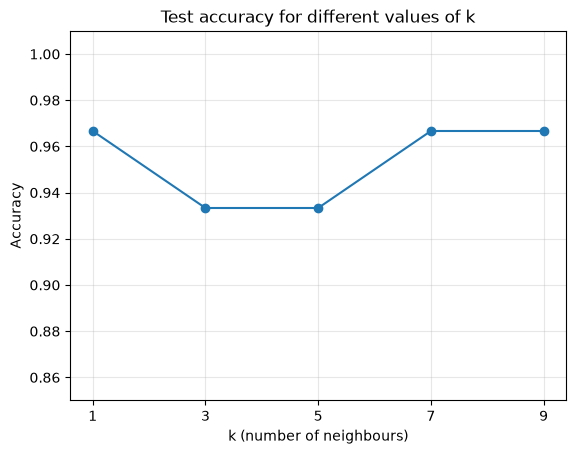

In [17]:
plt.plot(experiment_table["k"], experiment_table["accuracy"], marker="o")
plt.title("Test accuracy for different values of k")
plt.xlabel("k (number of neighbours)")
plt.ylabel("Accuracy")
plt.xticks([1, 3, 5, 7, 9])
plt.ylim(0.85, 1.01)
plt.grid(True, alpha=0.3)
plt.show()


### My experiment answers

**1. Which value of k produced the highest test accuracy?**  
k = 1, k = 7, and k = 9 are the best. The accuracy is about 0.967. k = 3 and k = 5 give 0.933.

**2. Did every value of k produce a different result?**  
No. Some values give the same score. k = 1, 7, and 9 are the same. k = 3 and 5 are also the same.

**3. Why is it unfair to claim that one setting is always best after testing only one small dataset?**  
This result is only for these 150 flowers and this split. On other data, the best k can change. One small test cannot show the best setting for all cases.


## 11. Optional comparison — A small neural network

A neural network is another classification model. In this first lesson I use a ready-made model. I do not need to understand backpropagation yet.

This network has:

- four input values;
- one hidden layer with eight neurons;
- three possible output classes.


In [18]:
neural_network = MLPClassifier(
    hidden_layer_sizes=(8,),
    max_iter=2000,
    random_state=RANDOM_STATE,
)
neural_network.fit(X_train_scaled, y_train)
neural_predictions = neural_network.predict(X_test_scaled)
neural_accuracy = accuracy_score(y_test, neural_predictions)

model_comparison = pd.DataFrame({
    "Model": ["k-NN (k=3)", "Small neural network"],
    "Test accuracy": [accuracy, neural_accuracy],
})
display(model_comparison.round(3))


,Model,Test accuracy
0,k-NN (k=3),0.933
1,Small neural network,0.933


### Think carefully

If the neural network has higher accuracy, does that automatically mean it is the best model?

**No.** I also look at simple use, speed, and how easy it is to explain. The dataset is small. A small difference can be only one test flower. Here both models have the same accuracy: 0.933. k-NN is easier to explain: it looks at nearby flowers. A harder model is not better only because it sounds smart.


## 12. Final reflection

I answer in my own words.

**1. What was the AI task in this practical work?**  
The task was to guess the kind of an Iris flower from four measurements: setosa, versicolor, or virginica.

**2. What is the difference between a feature and a label?**  
A feature is input data, like petal length. A label is the true answer, like the flower kind.

**3. What is the difference between training and prediction?**  
In training the model learns from flowers with known labels. In prediction the model gives answers for new flowers.

**4. Why did we keep a separate testing set?**  
I keep a test set to check the model on flowers it did not see in training. This is a fair check.

**5. Explain k-NN using a simple real-life analogy.**  
It is like asking friends. If I do not know a film, I ask some friends with a similar taste. I take the most common answer. In k-NN the "friends" are the nearest flowers.

**6. What does accuracy measure?**  
Accuracy measures how many answers are correct. I divide the number of correct answers by the total number of answers.

**7. What information does a confusion matrix provide?**  
It shows more than the total score. It shows which classes the model mixes. The diagonal is correct. Other cells are mistakes.

**8. Give one limitation of this experiment.**  
The dataset is small. I have only 150 flowers and 30 test flowers. I also use only one split.

**9. Give one responsible or ethical question that should be considered when AI is used for people instead of flowers.**  
If the model is wrong, who can get hurt? A wrong flower name is not a big problem. A wrong answer about a person can change a grade, a job, money, or health. So people need a fair check and a way to ask questions.

### Conclusion

In this work I trained a simple AI model on Iris flowers. The computer got four numbers and tried to guess the flower kind. I learned the words example, feature, label, training, prediction, and accuracy. I split the data, scaled the numbers, and trained k-NN. The model was correct 28 times out of 30, so accuracy was 93.3%. It mixed virginica and versicolor because these two kinds look similar. A high score on a small test is useful, but it does not mean the model is always right. The result depends on the data, the features, the algorithm, and settings like k.


## Key message from Lesson 1

An AI model learns patterns from examples. Its prediction depends on the data, features, algorithm, and settings. A high score on a small test set is useful, but it is not proof that the model is intelligent, fair, or always correct.
